In [50]:
from environment import CoronagraphEnvironment
import hcipy
from hcipy import *
from matplotlib import pyplot as plt
import numpy as np

In [96]:
NUM_MODES = 10
PIXEL_RESOLUTION = 64
OVERSIZNG_FACTOR = 1
NUM_AIRY=5
CORONAGRAPH_CHARGE = 6
PIXELS_PER_SPACIAL_RES = 2

e = CoronagraphEnvironment(
    num_modes=NUM_MODES,
    pixels=PIXEL_RESOLUTION,
    oversizing_factor=OVERSIZNG_FACTOR,
    num_airy=NUM_AIRY,
    coronagraph_charge=CORONAGRAPH_CHARGE,
    pixels_per_spacial_res=PIXELS_PER_SPACIAL_RES
)

initializing coronagraph env. might take a minute.


In [97]:
e.deformable_mirror.flatten()
print(f"theoretical min contrast: 10^{np.log10(e.get_contrast(delta_t=1e15)):.02f}")

theoretical min contrast: 10^-5.77


[ 3.03081267e-09  6.54546009e-08  4.64055749e-08  5.14890690e-09
 -2.57470103e-08 -4.52078466e-09 -1.16323278e-08  4.32408166e-08
  1.76444058e-09  2.88960590e-08]
0.0006061909042137067


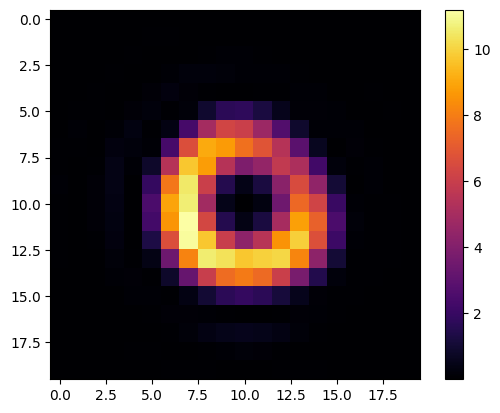

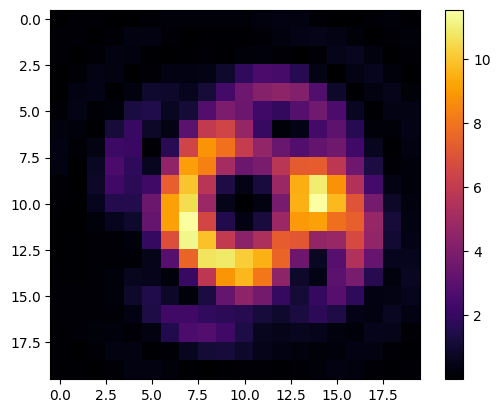

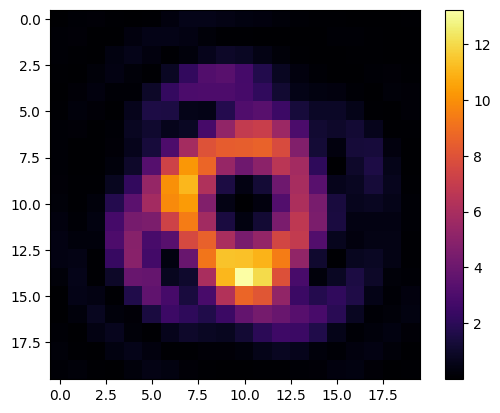

In [101]:
e.set_random_dm(noise=1e-7)
print(e.deformable_mirror.actuators)
print(e.get_contrast(delta_t=1e15))

image1 = e.get_camera_image(delta_t=1e-3, noise_enabled=False)
plt.imshow(image1, cmap="inferno")
plt.colorbar()
plt.show()

nudge=[0 for _ in range(NUM_MODES)]
nudge[0] = 3e-7
e.deformable_mirror.actuators += nudge
image2 = e.get_camera_image(delta_t=1e-3, noise_enabled=False)
plt.imshow(image2, cmap="inferno")
plt.colorbar()
plt.show()

e.deformable_mirror.actuators += [-2 * n for n in nudge]
image3 = e.get_camera_image(delta_t=1e-3, noise_enabled=False)
plt.imshow(image3, cmap="inferno")
plt.colorbar()
plt.show()



In [102]:
from tqdm import tqdm
import random
import pickle

# Build out a training dataset for a traditional CNN encoder.

# Example: Generate a dataset of N random DM settings and their corresponding images
N = 50000 # Number of samples

images = []
dm_profiles = []
dm_settings = []
slopes = []
noises = []
nudge=[0 for _ in range(NUM_MODES)]
nudge[0] = 3e-7
negative_nudge = [-n for n in nudge]

save_at = {1000, 5000, 10000, 25000, N}

for i in tqdm(range(N), desc="Building dataset"):
    noise = 1e-7
    e.deformable_mirror.flatten()
    e.set_random_dm(noise=noise)
    original_setting = e.deformable_mirror.actuators.copy()

    image1 = e.get_camera_image(delta_t=1e-3, noise_enabled=False)

    # nudge 1
    e.deformable_mirror.flatten()
    e.deformable_mirror.actuators = original_setting + nudge 
    image2 = e.get_camera_image(delta_t=1e-3, noise_enabled=False)

    # nudge 2
    e.deformable_mirror.flatten()
    e.deformable_mirror.actuators = original_setting - nudge 
    image3 = e.get_camera_image(delta_t=1e-3, noise_enabled=False)

    images.append((image1, image2, image3))
    dm_settings.append(original_setting)
    
    if i + 1 in save_at:
        print(f"saved {i+1} images")
        data = {
            "dm_settings": dm_settings,
            "images": images,
            "noises": noises
        }

        with open(f'data/V4 gen small_imgs {i + 1}.pkl', 'wb') as f:
            pickle.dump(data, f)

    


Building dataset:   2%|▏         | 1005/50000 [00:21<18:56, 43.12it/s]

saved 1000 images


Building dataset:  10%|█         | 5000/50000 [01:44<22:22, 33.51it/s]

saved 5000 images


Building dataset:  20%|█▉        | 9996/50000 [03:27<13:24, 49.76it/s]

...

Building dataset:  50%|████▉     | 24998/50000 [09:14<09:18, 44.73it/s]

saved 25000 images


Building dataset: 100%|█████████▉| 49997/50000 [18:57<00:00, 45.35it/s]

saved 50000 images


Building dataset: 100%|██████████| 50000/50000 [18:59<00:00, 43.89it/s]


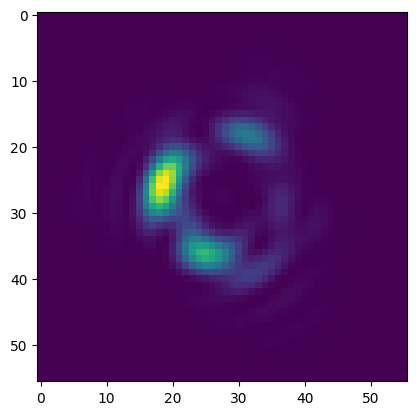

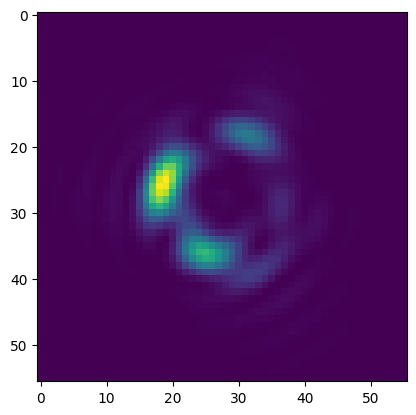

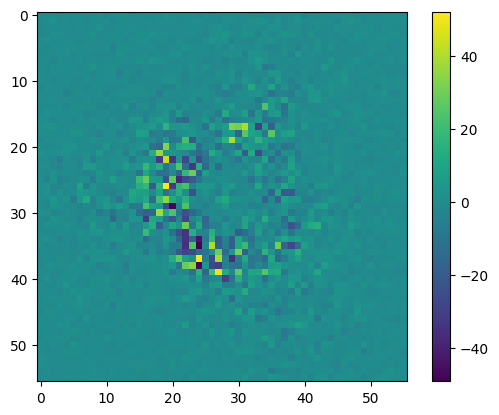

In [46]:
test_index = 0
e.deformable_mirror.flatten()
dm_proper = dm_settings[test_index]
img1 = images[test_index][0]
e.set_dm(dm_proper)
cam_img = 0.1 * e.get_camera_image(delta_t=10)

plt.imshow(img1)
plt.show()
plt.imshow(cam_img)
plt.show()
plt.imshow(img1 - cam_img)
plt.colorbar()

In [10]:
import pickle

data = {
    "dm_settings": dm_settings[:5000],
    "images": images[:5000],
    "noises": noises[:5000]
}

with open('data/V2 generator 3.pkl', 'wb') as f:
    pickle.dump(data, f)

# with open('data/V2 generator 1.pkl', 'rb') as f:
#     print(pickle.load(f))

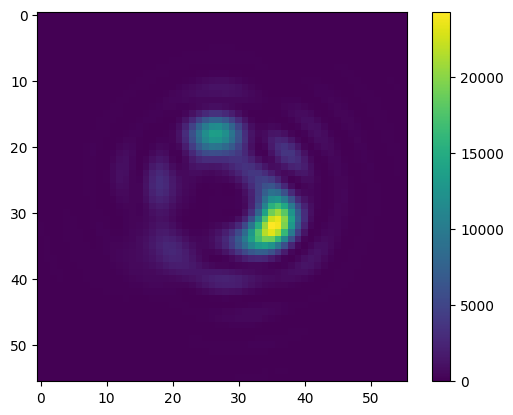

[ 3.13580387  0.63642574 -0.37630608 -0.3358459   0.26532845  0.04789495
 -0.07027078  0.16498058  0.16078096  0.09257143  0.0048598  -0.07803947
 -0.10115944 -0.11296977  0.1731254  -0.25251835  0.02027975 -0.03179843
  0.08169416  0.14044443  0.00828749  0.0268642  -0.16052388  0.07222527
  0.02020707]


In [70]:
plt.imshow(images[2][1])
plt.colorbar()
plt.show()
print(dm_settings[4] * 1e7)

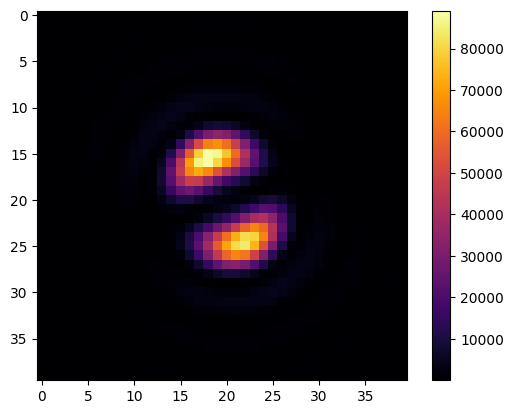

In [509]:
plt.imshow((images[-5] + 1), cmap="inferno")
plt.colorbar()

In [1]:
16 / 15 * 240

256.0

In [517]:
e2 = CoronagraphEnvironment(num_modes=200)

initializing coronagraph env. might take a minute.


ValueError: operands could not be broadcast together with shapes (200,) (5,) (200,) 

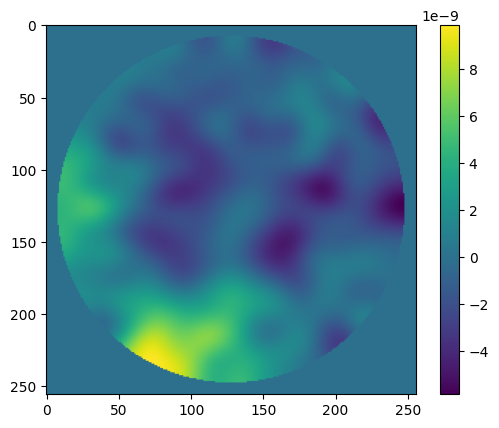

In [520]:
e2.deformable_mirror.flatten()
e2.set_random_dm(noise=0.001)
plt.imshow(np.reshape(e2.deformable_mirror.surface, shape=(256, 256)))
plt.colorbar()
plt.show()

In [525]:
np.sqrt(6400 )

np.float64(80.0)

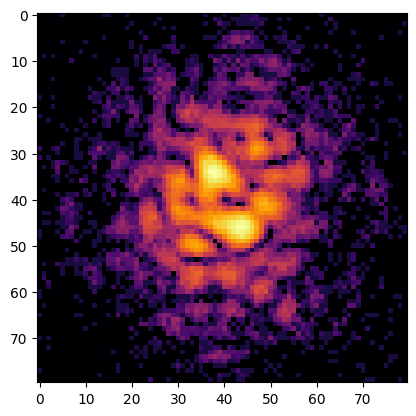

In [537]:
e2.set_random_dm(noise=0.001)
image = e2.get_camera_image(delta_t=1)
plt.imshow(np.reshape(np.log(image + 1), shape=(80,80)), cmap="inferno")
plt.show()


In [372]:
# Normalize dm_settings to zero mean and unit variance
dm_settings = np.array(dm_settings)
dm_mean = dm_settings.mean(axis=0)
dm_std = dm_settings.std(axis=0)
dm_settings_norm = (dm_settings - dm_mean) / (dm_std + 1e-8)

# Normalize slopes to zero mean and unit variance
slopes = np.array(slopes)
slopes_mean = slopes.mean(axis=0)
slopes_std = slopes.std(axis=0)
slopes_norm = (slopes - slopes_mean) / (slopes_std + 1e-8)

In [373]:
import pickle

for_export = {
    "dm_settings": dm_settings,
    "dm_settings_norm": dm_settings_norm,
    "slopes": slopes,
    "slopes_norm": slopes_norm,
    "images": images
}

with open('data/noise01/10000_samples_0.002_to_0.02_noise.pkl', 'wb') as f:
    pickle.dump(for_export, f)

In [374]:
from sklearn.model_selection import train_test_split

# Convert images (list of OldStyleField) to numpy arrays for ML usage
X = np.array([np.array(np.log(img + 1)) for img in images])
y = dm_settings_norm

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
import pickle

with open('data/noise01/10000_samples_0.002_to_0.02_noise.pkl', 'r') as f:
    imported_data = pickle.load(f)

dm_mean, dm_std = np.mean(imported_data["dm_settings"]), np.std(imported_data["dm_settings"]) 

UnicodeDecodeError: 'charmap' codec can't decode byte 0x81 in position 307: character maps to <undefined>

In [8]:
import torch

import torch.nn as nn
import torchvision.models as models

class LargeImageEncoderNet(nn.Module):
    def __init__(self, output_dim=10, input_shape=(40, 40)):
        super(LargeImageEncoderNet, self).__init__()
        h, w = input_shape
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(2304, 1024),
            nn.ReLU(),
            nn.Linear(1024, output_dim)
        )
        

    def forward(self, x):
        return self.encoder(x)

class SmallImageEncoderNet(nn.Module):
    def __init__(self, output_dim=10, input_shape=(40, 40)):
        super(SmallImageEncoderNet, self).__init__()

        height, width = input_shape

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Flatten(),

            nn.Linear(32 * height * width, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )
    
    def forward(self, img):
        return self.encoder(img)

# Example usage:
model = LargeImageEncoderNet(output_dim=5)
output = model(torch.randn(1, 1, 40, 40))  # Example input

In [376]:
# Prepare data for training
import torch.optim as optim

# Add channel dimension for grayscale images (shape: [batch, channel, height, width])
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)  # shape: [4000, 1, w, h]

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

# Initialize model, loss, and optimizer
model = LargeImageEncoderNet(output_dim=y_train.shape[1], input_shape=X_train_tensor[0].shape[1:])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [377]:
X_train_tensor.shape

torch.Size([8000, 1, 40, 40])

In [378]:
from torch.utils.data import DataLoader, TensorDataset

batch_size = 64
epochs = 500
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_X.size(0)
    avg_loss = epoch_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.10f}")


Epoch 1/500, Loss: 0.6646699097
Epoch 2/500, Loss: 0.3089282252
Epoch 3/500, Loss: 0.0951848855
Epoch 4/500, Loss: 0.0456862672
Epoch 5/500, Loss: 0.0266298478
Epoch 6/500, Loss: 0.0189115630
Epoch 7/500, Loss: 0.0167992962
Epoch 8/500, Loss: 0.0142435603
Epoch 9/500, Loss: 0.0140950734
Epoch 10/500, Loss: 0.0114248158
Epoch 11/500, Loss: 0.0114666392
Epoch 12/500, Loss: 0.0089571242
Epoch 13/500, Loss: 0.0098426201
Epoch 14/500, Loss: 0.0085287835
Epoch 15/500, Loss: 0.0086119526
Epoch 16/500, Loss: 0.0084901961
Epoch 17/500, Loss: 0.0088497651
Epoch 18/500, Loss: 0.0077103243
Epoch 19/500, Loss: 0.0079040587
Epoch 20/500, Loss: 0.0077943915
Epoch 21/500, Loss: 0.0081074396
Epoch 22/500, Loss: 0.0077142103
Epoch 23/500, Loss: 0.0073281122
Epoch 24/500, Loss: 0.0063675565
Epoch 25/500, Loss: 0.0068921651
Epoch 26/500, Loss: 0.0067279342
Epoch 27/500, Loss: 0.0061395180
Epoch 28/500, Loss: 0.0070226555
Epoch 29/500, Loss: 0.0064243987
Epoch 30/500, Loss: 0.0060711019
Epoch 31/500, Loss:

In [10]:
import torch

# Define the path to save the model
PATH = "models/CNN Large weights norm train extended.pth"

# Save the model's state_dict
# torch.save(model.state_dict(), PATH)

# Re-instantiate the model architecture before loading weights
model = LargeImageEncoderNet(output_dim=5, input_shape=(40, 40))
model.load_state_dict(torch.load(PATH))

<All keys matched successfully>

cuda


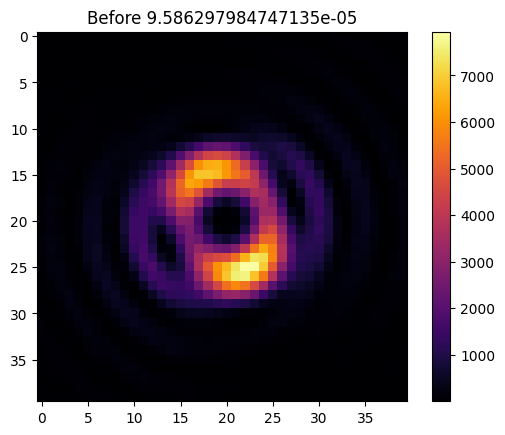

torch.Size([1, 1, 40, 40])


In [5]:
e.set_random_dm(noise=0.01)

plt.title(f'Before {e.get_contrast()}')
image = (crop_image(np.clip(e.get_camera_image(delta_t=1), a_min = 1e-20, a_max = None) + 1))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

image = np.array(image)

plt.imshow(image, cmap="inferno")
plt.colorbar()
plt.show()

image_tensor = torch.tensor(image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
print(image_tensor.shape)

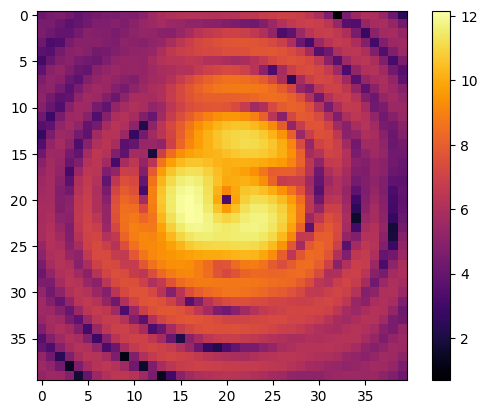

In [84]:
plt.imshow(np.log(images[0] + 1), cmap="inferno")
plt.colorbar()

cuda


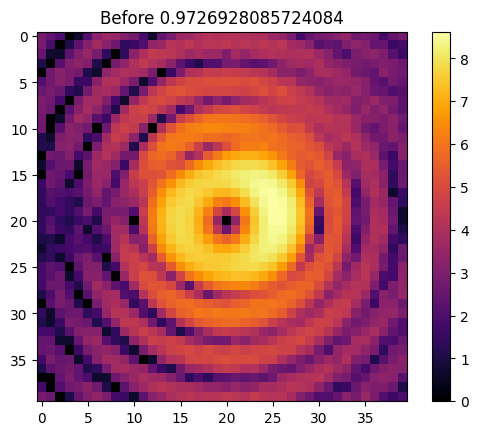

torch.Size([1, 1, 40, 40])
correction_prediction: tensor([[ 0.2894,  0.1096, -0.0470,  0.3327, -0.0026]])
correct answer: [ 2.90848498e-08  8.82762628e-08  8.57165783e-09  8.01257075e-10
 -3.45346188e-08]


C:\Users\alexe\AppData\Local\Temp\ipykernel_32112\425162999.py:29: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  e.set_dm(np.array(y_pred[0].to('cpu')) * dm_std + dm_mean)


NameError: name 'dm_std' is not defined

In [11]:
#e.deformable_mirror.flatten()
#e.set_dm(-dm_settings[10])
e.set_random_dm(0.011)

plt.title(f'Before {e.get_strehl_ratio()}')
image = np.log(crop_image(np.clip(e.get_camera_image(delta_t=1), a_min = 1e-20, a_max = None) + 1))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

image = np.array(image)

plt.imshow(image, cmap="inferno")
plt.colorbar()
plt.show()

image_tensor = torch.tensor(image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
print(image_tensor.shape)


#manual_test_torch = torch.tensor(image.transpose(0, 3, 1, 2), dtype=torch.float32)
#manual_test_torch = F.interpolate(manual_test_torch, size=(224, 224), mode='bilinear', align_corners=False)
#manual_test_torch = manual_test_torch.to(device)
with torch.no_grad():
    y_pred = model(image_tensor)
    print(f"correction_prediction: {y_pred}")
    print(f"correct answer: {-e.deformable_mirror.actuators}")

e.set_dm(np.array(y_pred[0].to('cpu')) * dm_std + dm_mean)

plt.title(f'After {e.get_strehl_ratio()}')

image = (crop_image(np.clip(e.get_camera_image(delta_t=1), a_min = 1e-20, a_max = None) + 1))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

image = np.array(image)

plt.imshow(image, cmap="inferno")
plt.colorbar()
plt.show()

In [484]:
from sklearn.model_selection import train_test_split

# Convert images (list of OldStyleField) to numpy arrays for ML usage
X = slopes_norm
y = dm_settings_norm

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [488]:
import torch

import torch.nn as nn

class SimpleSlopeToDMNet(nn.Module):
    def __init__(self, input_shape=(2, 1849), output_dim=5):
        super(SimpleSlopeToDMNet, self).__init__()
        input_dim = input_shape[0] * input_shape[1]
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# Example usage:
model = SimpleSlopeToDMNet(input_shape=(2, 1849), output_dim=5)
output = model(torch.randn(1, 2, 1849))  # Example input

In [489]:
import torch.optim as optim

# Add channel dimension for grayscale images (shape: [batch, channel, height, width])
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)  # shape: [4000, 1, w, h]

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

# Initialize model, loss, and optimizer
model = SimpleSlopeToDMNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [490]:
from torch.utils.data import DataLoader, TensorDataset

batch_size = 64
epochs = 500
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_X.size(0)
    avg_loss = epoch_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.10f}")

Epoch 1/500, Loss: 0.0249021835
Epoch 2/500, Loss: 0.0020898408
Epoch 3/500, Loss: 0.0022571617
Epoch 4/500, Loss: 0.0015864138
Epoch 5/500, Loss: 0.0016213925
Epoch 6/500, Loss: 0.0015973647
Epoch 7/500, Loss: 0.0015347452
Epoch 8/500, Loss: 0.0012071392
Epoch 9/500, Loss: 0.0009327494
Epoch 10/500, Loss: 0.0009483645
Epoch 11/500, Loss: 0.0011004063
Epoch 12/500, Loss: 0.0011978118
Epoch 13/500, Loss: 0.0006290872
Epoch 14/500, Loss: 0.0011449176
Epoch 15/500, Loss: 0.0008212733
Epoch 16/500, Loss: 0.0005203500
Epoch 17/500, Loss: 0.0009132876
Epoch 18/500, Loss: 0.0010473868
Epoch 19/500, Loss: 0.0006447090
Epoch 20/500, Loss: 0.0004678243
Epoch 21/500, Loss: 0.0005988409
Epoch 22/500, Loss: 0.0010563952
Epoch 23/500, Loss: 0.0010905826
Epoch 24/500, Loss: 0.0005281930
Epoch 25/500, Loss: 0.0004090695
Epoch 26/500, Loss: 0.0009297049
Epoch 27/500, Loss: 0.0018546537
Epoch 28/500, Loss: 0.0007940746
Epoch 29/500, Loss: 0.0002933578
Epoch 30/500, Loss: 0.0005389402
Epoch 31/500, Loss:

KeyboardInterrupt: 

cuda


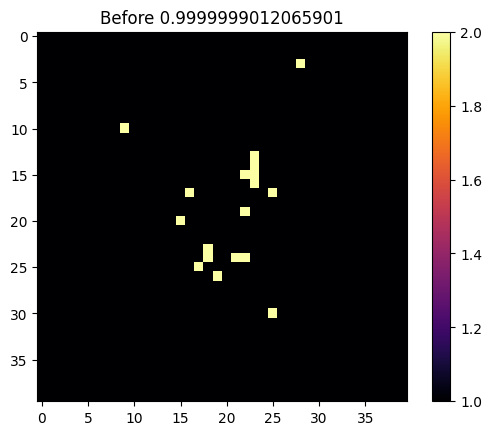

flat_slope shape: torch.Size([1, 3698])
correction_prediction: tensor([[-0.0044,  0.0009, -0.0058,  0.0083, -0.0165]])
correct answer: [ 6.29722280e-11 -1.50602717e-10 -2.58983695e-11  3.26519777e-11
  9.17298719e-11]


C:\Users\alexe\AppData\Local\Temp\ipykernel_13128\2297006924.py:30: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  e.set_dm(np.array(y_pred[0].to('cpu')) * dm_std + dm_mean)


cuda


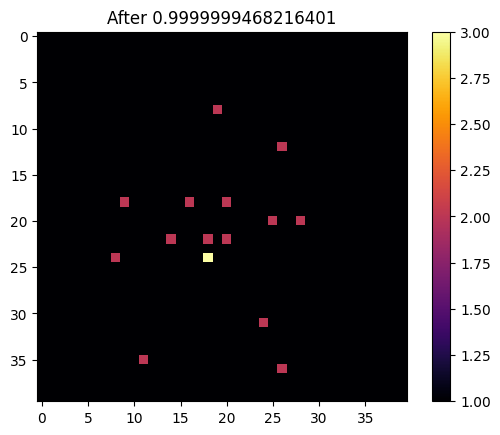

In [506]:
#e.deformable_mirror.flatten()
#e.set_dm(-dm_settings[10])
# e.set_random_dm(0.011)

plt.title(f'Before {e.get_strehl_ratio()}')
image = (crop_image(np.clip(e.get_camera_image(delta_t=1), a_min = 1e-20, a_max = None) + 1))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

image = np.array(image)

plt.imshow(image, cmap="inferno")
plt.colorbar()
plt.show()

slope_tensor = torch.tensor((e.get_slopes() - slopes_mean) / slopes_std, dtype=torch.float32)


#manual_test_torch = torch.tensor(image.transpose(0, 3, 1, 2), dtype=torch.float32)
#manual_test_torch = F.interpolate(manual_test_torch, size=(224, 224), mode='bilinear', align_corners=False)
#manual_test_torch = manual_test_torch.to(device)
with torch.no_grad():
    flat_slope = slope_tensor.flatten().unsqueeze(0)
    print(f"flat_slope shape: {flat_slope.shape}")
    y_pred = model(flat_slope)
    print(f"correction_prediction: {y_pred}")
    print(f"correct answer: {-e.deformable_mirror.actuators}")

e.set_dm(np.array(y_pred[0].to('cpu')) * dm_std + dm_mean)

plt.title(f'After {e.get_strehl_ratio()}')

image = (crop_image(np.clip(e.get_camera_image(delta_t=1), a_min = 1e-20, a_max = None) + 1))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

image = np.array(image)

plt.imshow(image, cmap="inferno")
plt.colorbar()
plt.show()

In [492]:
2 * 1849 

3698

In [487]:
dm_settings_norm.shape

(10000, 5)

# Old Code


C:\Users\alexe\AppData\Local\Temp\ipykernel_45672\133515688.py:26: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  e.set_dm(0.05 * (np.array(y_pred[0].to('cpu')) * dm_std + dm_mean))


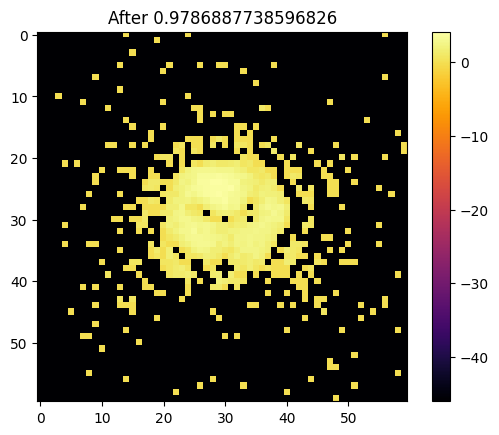

In [164]:
for _ in range(10):
    image = [np.log(np.clip(e.get_camera_image(), a_min = 1e-8, a_max = None))]

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    image = np.array(image)

    image_size = image.shape[-1]

    image_reshaped = image.reshape(
        (int(np.sqrt(image_size))), int(np.sqrt(image_size))
    )

    h, w = image_reshaped.shape[0], image_reshaped.shape[1]
    start_h = (h - 60) // 2
    start_w = (w - 60) // 2
    image_cropped = image_reshaped[start_h:start_h+60, start_w:start_w+60]

    image_tensor = torch.tensor(image_cropped, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

    #manual_test_torch = torch.tensor(image.transpose(0, 3, 1, 2), dtype=torch.float32)
    #manual_test_torch = F.interpolate(manual_test_torch, size=(224, 224), mode='bilinear', align_corners=False)
    #manual_test_torch = manual_test_torch.to(device)
    with torch.no_grad():
        y_pred = model(image_tensor)
    e.set_dm(0.05 * (np.array(y_pred[0].to('cpu')) * dm_std + dm_mean))

plt.title(f'After {e.get_strehl_ratio()}')
image = [np.log(np.clip(e.get_camera_image(), a_min = 10 ** -20, a_max = None))]

image = np.array(image)

image_size = image.shape[-1]

image_reshaped = image.reshape(
    (int(np.sqrt(image_size))), int(np.sqrt(image_size))
)

h, w = image_reshaped.shape[0], image_reshaped.shape[1]
start_h = (h - 60) // 2
start_w = (w - 60) // 2
image_cropped = image_reshaped[start_h:start_h+60, start_w:start_w+60]

plt.imshow(image_cropped, cmap='inferno')
plt.colorbar()
plt.show()

In [172]:
y_train_tensor.shape

torch.Size([4000, 10])

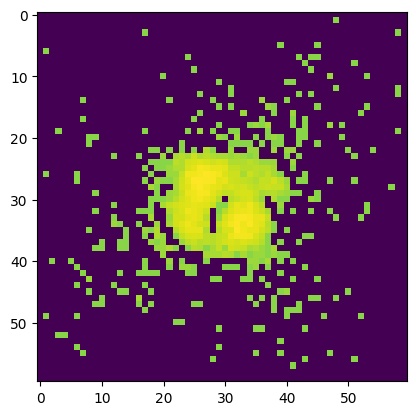

In [193]:
plt.imshow(X_train_tensor[0][0])


In [ ]:
# DO TRAINING 
# DO CHARTER
"Identified a cybersecurity risk exposed in Kenvue automation and AI"

y_pred: [-4.94019648e-09  2.96007115e-08  1.97601998e-08  2.46451401e-08
 -4.22775358e-09 -3.82127950e-08  3.52473913e-08  2.00435401e-09
 -1.10813715e-08  2.16169580e-08]
normal = [-9.78013422e-09  3.15294996e-08  1.56225570e-08  2.66921261e-08
 -7.16825244e-10 -4.54054857e-08  3.41027649e-08  1.61706350e-09
 -1.39797426e-08  2.42405511e-08]
after = [ 9.78013422e-09 -3.15294996e-08 -1.56225570e-08 -2.66921261e-08
  7.16825244e-10  4.54054857e-08 -3.41027649e-08 -1.61706350e-09
  1.39797426e-08 -2.42405511e-08]


C:\Users\alexe\AppData\Local\Temp\ipykernel_45672\1838549156.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  e.set_dm(np.array(-y_train_tensor[0]) * dm_std + dm_mean)
C:\Users\alexe\AppData\Local\Temp\ipykernel_45672\1838549156.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  print(f"y_pred: {np.array(y_pred[0].to('cpu')) * dm_std + dm_mean}")


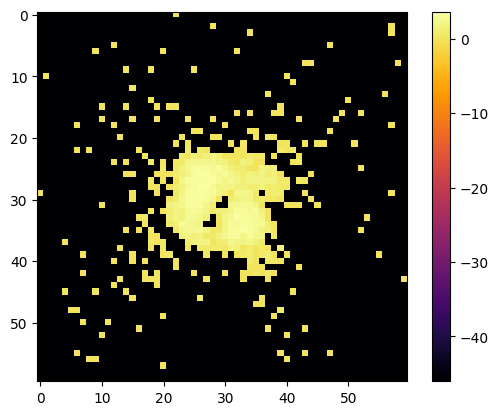

In [435]:
e.deformable_mirror.flatten()
e.set_dm(np.array(-y_train_tensor[0]) * dm_std + dm_mean)

with torch.no_grad():
    y_pred = model(X_train_tensor[0].unsqueeze(0))

print(f"y_pred: {np.array(y_pred[0].to('cpu')) * dm_std + dm_mean}")
print(f"normal = {-e.deformable_mirror.actuators}")

# e.set_dm(np.array(y_pred[0].to('cpu')) * dm_std + dm_mean )
print(f"after = {e.deformable_mirror.actuators}")

image = [np.log(np.clip(e.get_camera_image(), a_min = 10 ** -20, a_max = None))]

image = np.array(image)

image_size = image.shape[-1]

image_reshaped = image.reshape(
    (int(np.sqrt(image_size))), int(np.sqrt(image_size))
)

h, w = image_reshaped.shape[0], image_reshaped.shape[1]
start_h = (h - 60) // 2
start_w = (w - 60) // 2
image_cropped = image_reshaped[start_h:start_h+60, start_w:start_w+60]

plt.imshow(image_cropped, cmap='inferno')
plt.colorbar()
plt.show()

### Below is old code, not using new image cropping technique

In [98]:
from sklearn.model_selection import train_test_split

# Convert images (list of OldStyleField) to numpy arrays for ML usage
X = np.array([np.array(slope) for slope in slopes_norm])
y = dm_settings_norm

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Training loop
epochs = 500
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

In [99]:
import torch

import torch.nn as nn
import torchvision.models as models

class LargeImageEncoderNet(nn.Module):
    def __init__(self, output_dim=500, input_shape=(3, 224, 224)):
        super(LargeImageEncoderNet, self).__init__()
        h, w = input_shape
        self.encoder = nn.Sequential(
            nn.Linear(h * w, 2048),
            nn.ReLU(),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, output_dim)
        )
        

    def forward(self, x):
        return self.encoder(x)
    
    

# Example usage:
# model = LargeImageEncoderNet(output_dim=500)
# output = model(torch.randn(1, 3, 224, 224))  # Example input

In [ ]:
# Prepare data for training
import torch.optim as optim

# Flatten X_train if needed (currently shape: (800, 2, 1849))
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_train_tensor = torch.tensor(X_train_flat, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

# Initialize model, loss, and optimizer
model = LargeImageEncoderNet(output_dim=y_train.shape[1], input_shape=(2, 1849))
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [13]:
# Training loop
epochs = 500
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

RuntimeError: Given groups=1, weight of size [32, 1, 5, 5], expected input[1, 4000, 240, 240] to have 1 channels, but got 4000 channels instead

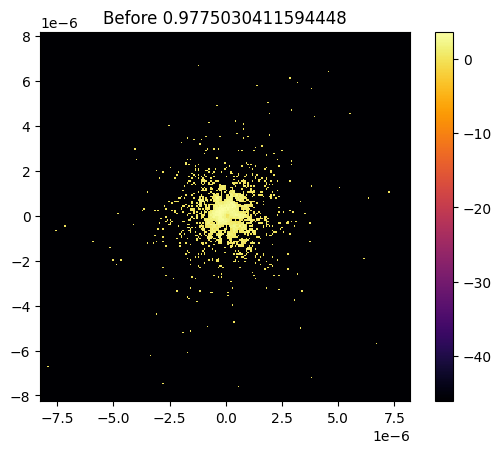

cuda


C:\Users\alexe\AppData\Local\Temp\ipykernel_36284\1351517651.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  e.set_dm(np.array(y_pred[0].to('cpu')) * dm_std + dm_mean)


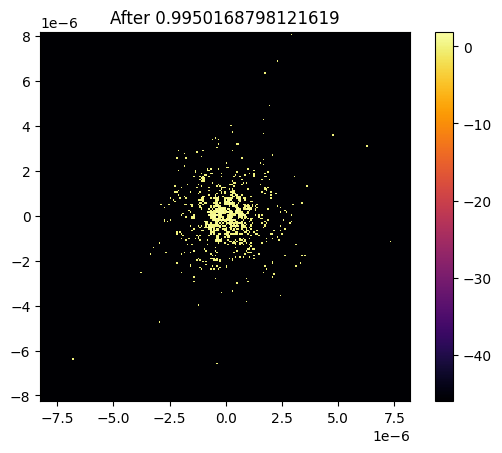

In [185]:
e.set_random_dm(noise=0.01)

plt.title(f'Before {e.get_strehl_ratio()}')
image = [np.log(np.clip(e.get_camera_image(), a_min = 10 ** -20, a_max = None))]

imshow_field(image[0], cmap='inferno')
plt.colorbar()
plt.show()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
test_slope_standard = torch.tensor((e.get_slopes() - slopes_mean) / slopes_std, dtype=torch.float32).to('cpu')
test_slope_standard = test_slope_standard.reshape(1, -1)


#manual_test_torch = torch.tensor(image.transpose(0, 3, 1, 2), dtype=torch.float32)
#manual_test_torch = F.interpolate(manual_test_torch, size=(224, 224), mode='bilinear', align_corners=False)
#manual_test_torch = manual_test_torch.to(device)
with torch.no_grad():
    y_pred = model(test_slope_standard)

e.set_dm(np.array(y_pred[0].to('cpu')) * dm_std + dm_mean)

plt.title(f'After {e.get_strehl_ratio()}')
image = [np.log(np.clip(e.get_camera_image(), a_min = 10 ** -20, a_max = None))]

imshow_field(image[0], cmap='inferno')
plt.colorbar()
plt.show()

In [313]:
e.set_random_dm(noise=0.01)
slopes = e.get_slopes()
print(np.min(slopes))
print(np.max(e.get_camera_image().shape))

-3.644932422316137e-05
57600


C:\Users\alexe\AppData\Local\Temp\ipykernel_36284\1540029973.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  e.set_dm(np.array(y_pred[0].to('cpu')) * dm_std + dm_mean)


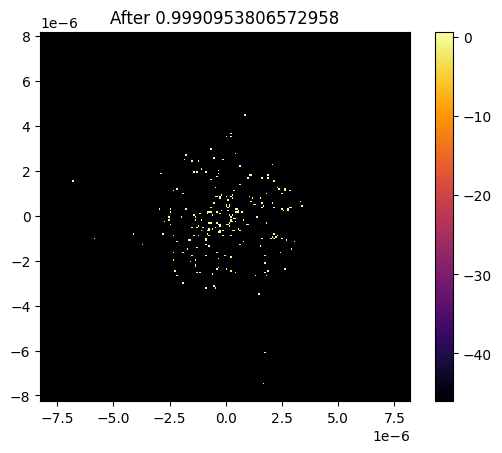

In [202]:
for _ in range(10):
    test_slope_standard = torch.tensor((e.get_slopes() - slopes_mean) / slopes_std, dtype=torch.float32).to('cpu')
    test_slope_standard = test_slope_standard.reshape(1, -1)


    #manual_test_torch = torch.tensor(image.transpose(0, 3, 1, 2), dtype=torch.float32)
    #manual_test_torch = F.interpolate(manual_test_torch, size=(224, 224), mode='bilinear', align_corners=False)
    #manual_test_torch = manual_test_torch.to(device)
    with torch.no_grad():
        y_pred = model(test_slope_standard)
    e.set_dm(np.array(y_pred[0].to('cpu')) * dm_std + dm_mean)

plt.title(f'After {e.get_strehl_ratio()}')
image = [np.log(np.clip(e.get_camera_image(), a_min = 10 ** -20, a_max = None))]

imshow_field(image[0], cmap='inferno')
plt.colorbar()
plt.show()